In [10]:
import ee
import geemap
import time

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='remote-sensing-final-495416')

In [11]:
# Cell 2 — Define ROI (Hammer Fire, El Paso County CO)
roi = ee.Geometry.Polygon([
    [
        [-104.65, 38.65],  # NW
        [-104.30, 38.65],  # NE
        [-104.30, 38.45],  # SE
        [-104.65, 38.45],  # SW
        [-104.65, 38.65]   # Close polygon
    ]
])

In [12]:
# Cell 3 — Cloud masking function
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask  = 1 << 10  # Bit 10 = opaque clouds
    cirrus_bit_mask = 1 << 11  # Bit 11 = cirrus
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )
    return image.updateMask(mask).divide(10000)

In [13]:
# Cell 4 — Load Sentinel-2 pre/post collections
S2 = 'COPERNICUS/S2_SR_HARMONIZED'
CLOUD_THRESHOLD = 20

col_pre = (
    ee.ImageCollection(S2)
    .filterBounds(roi)
    .filterDate('2026-04-10', '2026-04-21')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_THRESHOLD))
    .map(mask_s2_clouds)
)

col_post = (
    ee.ImageCollection(S2)
    .filterBounds(roi)
    .filterDate('2026-04-24', '2026-05-05')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_THRESHOLD))
    .map(mask_s2_clouds)
)

img_pre  = col_pre.median().clip(roi)
img_post = col_post.median().clip(roi)

print('Pre-fire scenes found: ',  col_pre.size().getInfo())
print('Post-fire scenes found:', col_post.size().getInfo())

Pre-fire scenes found:  1
Post-fire scenes found: 1


In [14]:
# Cell 5 — Compute NBR and dNBR
def compute_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

nbr_pre  = compute_nbr(img_pre)
nbr_post = compute_nbr(img_post)
dnbr     = nbr_pre.subtract(nbr_post).rename('dNBR')

# USGS severity thresholds:
# dNBR >= 0.10 -> Low
# dNBR >= 0.27 -> Moderate
# dNBR >= 0.44 -> High
burn_mask = dnbr.gte(0.1).rename('burned')

In [15]:
# Cell 6 — Estimate burned area in km2
pixel_area = ee.Image.pixelArea()

burned_area_m2 = (
    burn_mask
    .multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e13
    )
)

burned_km2 = ee.Number(burned_area_m2.get('burned')).divide(1e6)
print(f'Estimated burned area: {burned_km2.getInfo():.2f} km2')
print(f'Reference (official):  ~20.07 km2  (4,958 acres)')

Estimated burned area: 11.75 km2
Reference (official):  ~20.07 km2  (4,958 acres)


In [16]:
# Cell 7 — Visualize in geemap
Map = geemap.Map(center=[38.55, -104.47], zoom=11)

vis_rgb  = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}
vis_dnbr = {'min': -0.5, 'max': 1.0,
             'palette': ['blue', 'white', 'yellow', 'orange', 'red']}
vis_burn = {'min': 0, 'max': 1, 'palette': ['white', 'darkred']}

Map.addLayer(img_pre,   vis_rgb,   'Pre-fire RGB  (Apr 10-21)')
Map.addLayer(img_post,  vis_rgb,   'Post-fire RGB (Apr 24 - May 5)')
Map.addLayer(dnbr,      vis_dnbr,  'dNBR (burn severity)')
Map.addLayer(burn_mask, vis_burn,  'Burn mask (dNBR >= 0.1)')
Map.addLayerControl()
Map

Map(center=[38.55, -104.47], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [17]:
# Cell 8 — Export to Google Drive
EXPORT_FOLDER = 'Remote-Sensing-Final/HammerFire_2026'
SCALE      = 10
MAX_PIXELS = 1e13

exports = [
    {'image': img_pre.select(['B2','B3','B4','B8','B11','B12']),
     'description': 'hammer_fire_pre_s2',
     'prefix':      'hammer_fire_pre_sentinel2'},
    {'image': img_post.select(['B2','B3','B4','B8','B11','B12']),
     'description': 'hammer_fire_post_s2',
     'prefix':      'hammer_fire_post_sentinel2'},
    {'image': dnbr,
     'description': 'hammer_fire_dnbr',
     'prefix':      'hammer_fire_dnbr'},
    {'image': burn_mask,
     'description': 'hammer_fire_burn_mask',
     'prefix':      'hammer_fire_burn_mask'},
]

tasks = []
for exp in exports:
    task = ee.batch.Export.image.toDrive(
        image=exp['image'],
        description=exp['description'],
        folder=EXPORT_FOLDER,
        fileNamePrefix=exp['prefix'],
        scale=SCALE,
        region=roi,
        fileFormat='GeoTIFF',
        maxPixels=MAX_PIXELS
    )
    task.start()
    tasks.append(task)
    print(f"Started: {exp['description']}")

print('\nWaiting for tasks to register...')
time.sleep(5)

for task in ee.batch.Task.list()[:len(exports)]:
    s = task.status()
    print(f"[{s['state']:12s}] {s['description']}")

Started: hammer_fire_pre_s2
Started: hammer_fire_post_s2
Started: hammer_fire_dnbr
Started: hammer_fire_burn_mask

Waiting for tasks to register...
[READY       ] hammer_fire_burn_mask
[READY       ] hammer_fire_dnbr
[RUNNING     ] hammer_fire_post_s2
[RUNNING     ] hammer_fire_pre_s2


In [21]:
import requests
import os

os.makedirs('/content/hammer_fire_pngs', exist_ok=True)

viz_params = [
    {
        'image': img_pre,
        'name': 'png_pre_fire_rgb',
        'vis': {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3, 'dimensions': 2048, 'region': roi, 'format': 'PNG'}
    },
    {
        'image': img_post,
        'name': 'png_post_fire_rgb',
        'vis': {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3, 'dimensions': 2048, 'region': roi, 'format': 'PNG'}
    },
    {
        'image': dnbr,
        'name': 'png_dnbr',
        'vis': {'bands': ['dNBR'], 'min': -0.5, 'max': 1.0,
                'palette': ['blue', 'white', 'yellow', 'orange', 'red'],
                'dimensions': 2048, 'region': roi, 'format': 'PNG'}
    },
    {
        'image': burn_mask,
        'name': 'png_burn_mask',
        'vis': {'bands': ['burned'], 'min': 0, 'max': 1,
                'palette': ['white', 'darkred'],
                'dimensions': 2048, 'region': roi, 'format': 'PNG'}
    },
]

for v in viz_params:
    url = v['image'].getThumbURL(v['vis'])
    response = requests.get(url)
    filepath = f"/content/hammer_fire_pngs/{v['name']}.png"
    with open(filepath, 'wb') as f:
        f.write(response.content)
    print(f"Saved: {filepath}")

# Copy folder to Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    '/content/hammer_fire_pngs',
    '/content/drive/MyDrive/Remote-Sensing-Final/HammerFire_2026/PNGs',
    dirs_exist_ok=True
)
print('\nAll PNGs copied to Google Drive at:')
print('My Drive > Remote-Sensing-Final > HammerFire_2026 > PNGs')

Saved: /content/hammer_fire_pngs/png_pre_fire_rgb.png
Saved: /content/hammer_fire_pngs/png_post_fire_rgb.png
Saved: /content/hammer_fire_pngs/png_dnbr.png
Saved: /content/hammer_fire_pngs/png_burn_mask.png
Mounted at /content/drive

All PNGs copied to Google Drive at:
My Drive > Remote-Sensing-Final > HammerFire_2026 > PNGs


Fetching layers from GEE...
All layers fetched. Compositing map...


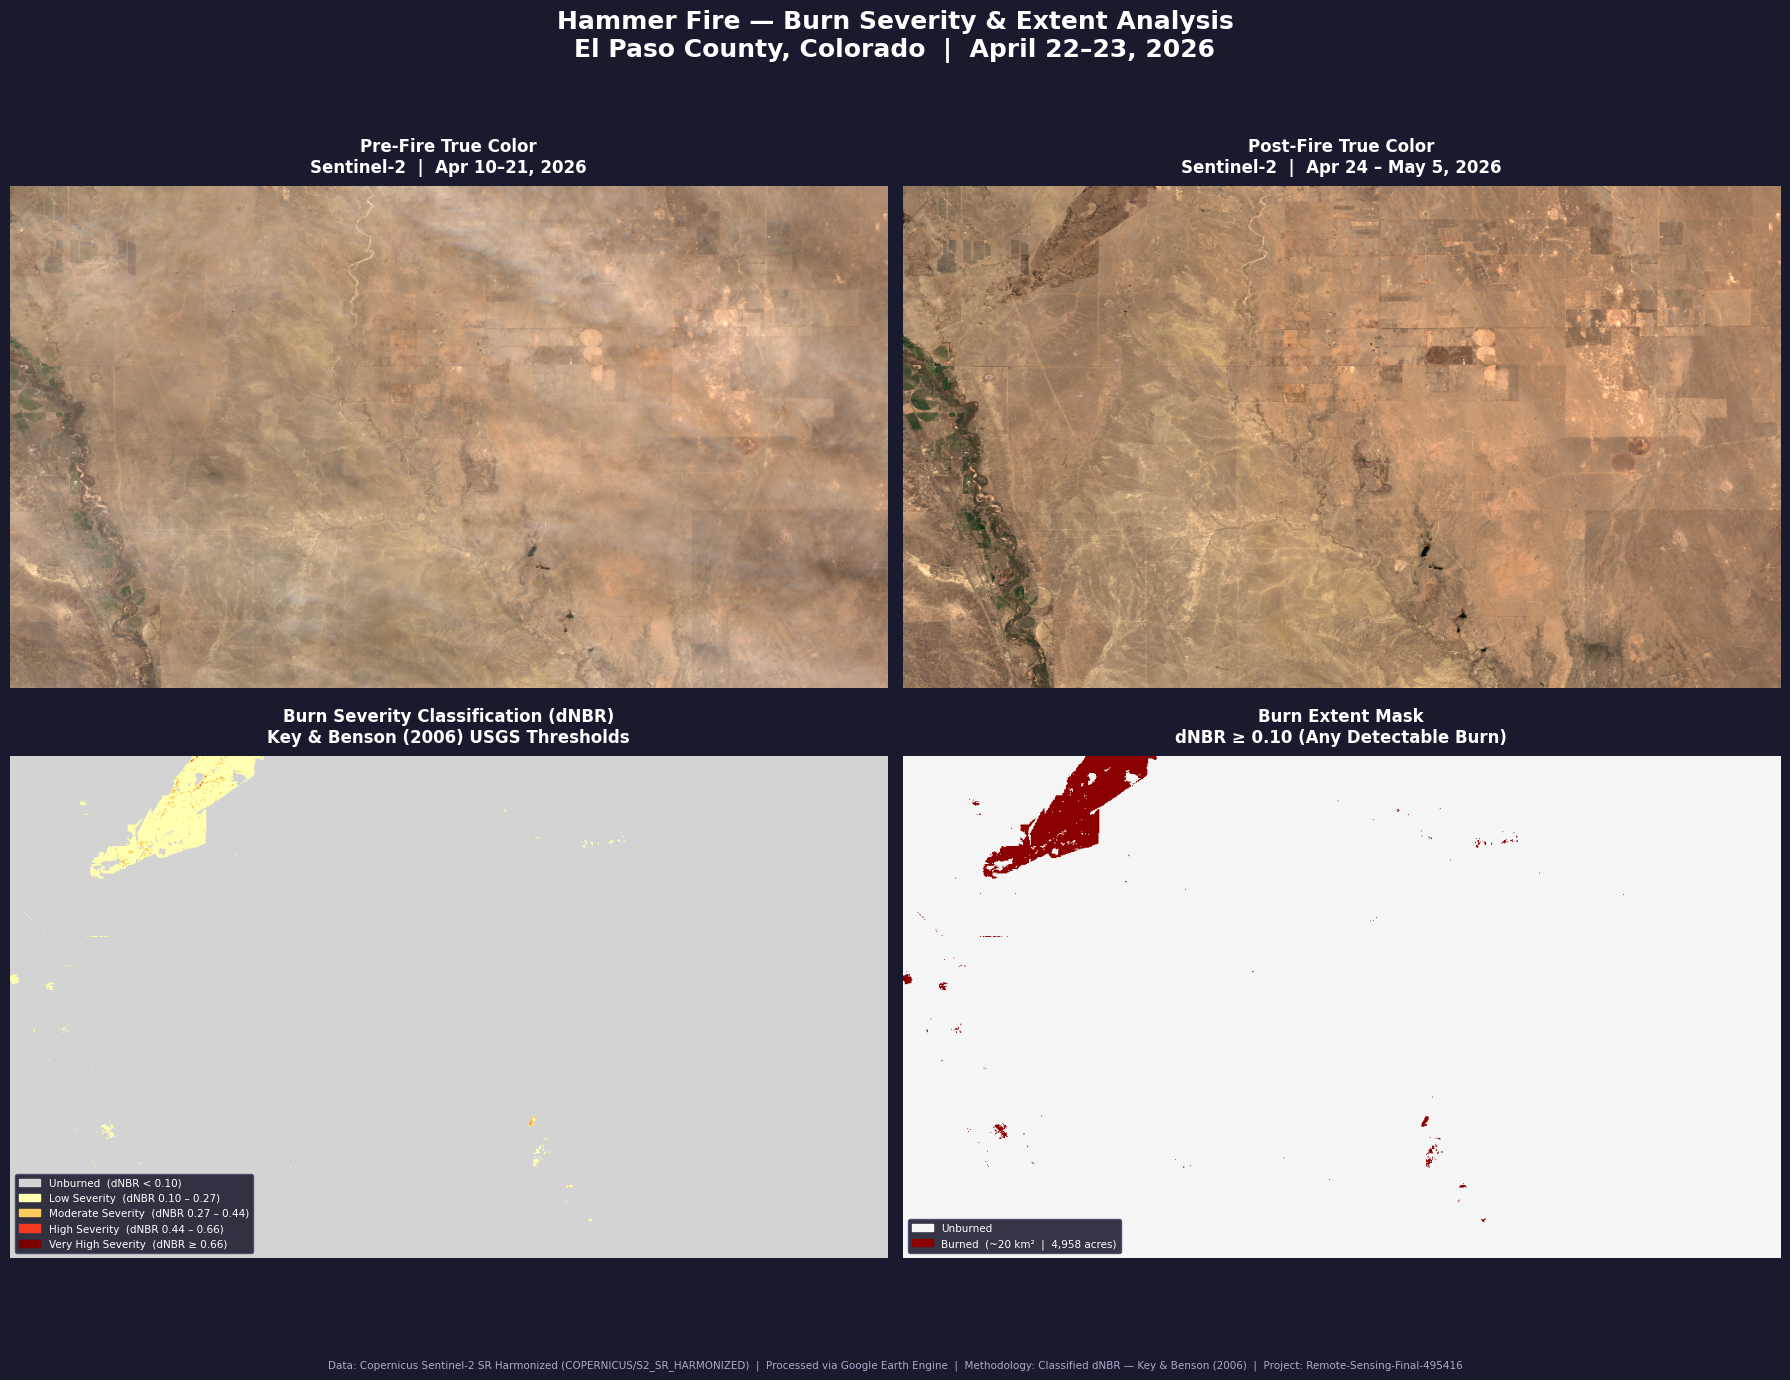

Map saved. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from google.colab import files

# ---------------------------------------------------------
# Pull each layer as a thumbnail from GEE
# Using discrete classified palette for dNBR so colors
# map exactly to USGS severity thresholds, not a stretch
# ---------------------------------------------------------
thumb_params = {
    'region': roi.getInfo()['coordinates'],
    'dimensions': 1024,
    'format': 'PNG'
}

def get_thumb(image, vis):
    params = {**thumb_params, **vis}
    url = image.getThumbURL(params)
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert('RGB')

print('Fetching layers from GEE...')

img_pre_thumb  = get_thumb(img_pre,  {'bands': ['B4','B3','B2'], 'min': 0, 'max': 0.3})
img_post_thumb = get_thumb(img_post, {'bands': ['B4','B3','B2'], 'min': 0, 'max': 0.3})
burn_thumb     = get_thumb(burn_mask,{'bands': ['burned'], 'min': 0, 'max': 1,
                                      'palette': ['#f5f5f5','#8b0000']})

# ---------------------------------------------------------
# dNBR — build a classified image in GEE before thumbnailing
# Each severity class gets a unique integer value:
#   0 = unburned       (dNBR < 0.10)
#   1 = low            (0.10 – 0.269)
#   2 = moderate       (0.27 – 0.439)
#   3 = high           (0.44 – 0.659)
#   4 = very high      (>= 0.66)
# Then map those integers to exact colors — no interpolation
# ---------------------------------------------------------
dnbr_classified = (
    dnbr.where(dnbr.lt(0.10),                            0)
        .where(dnbr.gte(0.10).And(dnbr.lt(0.27)),        1)
        .where(dnbr.gte(0.27).And(dnbr.lt(0.44)),        2)
        .where(dnbr.gte(0.44).And(dnbr.lt(0.66)),        3)
        .where(dnbr.gte(0.66),                            4)
)

dnbr_thumb = get_thumb(
    dnbr_classified,
    {
        'bands': ['dNBR'],
        'min': 0,
        'max': 4,
        'palette': [
            '#d3d3d3',  # 0 — unburned (light grey)
            '#ffffb2',  # 1 — low severity (light yellow)
            '#fecc5c',  # 2 — moderate severity (orange-yellow)
            '#f03b20',  # 3 — high severity (red-orange)
            '#7a0000',  # 4 — very high severity (dark red)
        ]
    }
)

print('All layers fetched. Compositing map...')

# ---------------------------------------------------------
# Build the 2x2 figure
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#1a1a2e')

titles = [
    'Pre-Fire True Color\nSentinel-2  |  Apr 10–21, 2026',
    'Post-Fire True Color\nSentinel-2  |  Apr 24 – May 5, 2026',
    'Burn Severity Classification (dNBR)\nKey & Benson (2006) USGS Thresholds',
    'Burn Extent Mask\ndNBR ≥ 0.10 (Any Detectable Burn)'
]

images = [img_pre_thumb, img_post_thumb, dnbr_thumb, burn_thumb]

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# --- dNBR discrete legend (panel 3) ---
ax_dnbr = axes[1][0]
severity_classes = [
    ('#d3d3d3', 'Unburned  (dNBR < 0.10)'),
    ('#ffffb2', 'Low Severity  (dNBR 0.10 – 0.27)'),
    ('#fecc5c', 'Moderate Severity  (dNBR 0.27 – 0.44)'),
    ('#f03b20', 'High Severity  (dNBR 0.44 – 0.66)'),
    ('#7a0000', 'Very High Severity  (dNBR ≥ 0.66)'),
]
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in severity_classes]
ax_dnbr.legend(
    handles=legend_patches,
    loc='lower left',
    fontsize=7.5,
    framealpha=0.88,
    facecolor='#1a1a2e',
    labelcolor='white',
    edgecolor='#444466'
)

# --- Burn mask legend (panel 4) ---
ax_burn = axes[1][1]
burn_patches = [
    mpatches.Patch(color='#f5f5f5', label='Unburned'),
    mpatches.Patch(color='#8b0000', label='Burned  (~20 km²  |  4,958 acres)'),
]
ax_burn.legend(
    handles=burn_patches,
    loc='lower left',
    fontsize=7.5,
    framealpha=0.88,
    facecolor='#1a1a2e',
    labelcolor='white',
    edgecolor='#444466'
)

# ---------------------------------------------------------
# Title block and footer
# ---------------------------------------------------------
fig.suptitle(
    'Hammer Fire — Burn Severity & Extent Analysis\nEl Paso County, Colorado  |  April 22–23, 2026',
    color='white', fontsize=18, fontweight='bold', y=0.98
)

fig.text(
    0.5, 0.01,
    'Data: Copernicus Sentinel-2 SR Harmonized (COPERNICUS/S2_SR_HARMONIZED)  |  '
    'Processed via Google Earth Engine  |  '
    'Methodology: Classified dNBR — Key & Benson (2006)  |  '
    'Project: Remote-Sensing-Final-495416',
    ha='center', color='#aaaacc', fontsize=7.5
)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# ---------------------------------------------------------
# Save and auto-download
# ---------------------------------------------------------
output_path = '/content/hammer_fire_map_fixed.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Map saved. Downloading...')
files.download(output_path)